# Complete shared-candidate WCCI full-test analysis

This notebook inventories every full-test result currently downloaded
under `outputs/full_test_eval/shared` and combines all comparable
**50-chronic `bus36_wcci_nomaint` evaluations**:

- 80 original zero-shot runs across NL/NLS and action caps
  64/128/256/512/1024;
- eight early WCCI fine-tuned mk256 checkpoints;
- eight evaluation-only rho-gating runs on fine-tuned checkpoints;
- sixteen evaluation-only local-rho runs on original NLS checkpoints
  at mk64 and mk256;
- the target-trained WCCI MLP comparator when available.

The 201-episode bus14 source-grid evaluations are inventoried and
reported separately. They are not mixed with WCCI rankings because
the environments and chronic sets differ.

**Important:** the same 50 WCCI test chronics have now been inspected
repeatedly while choosing action caps and rho thresholds. Results are
therefore exploratory model-selection evidence, not an unbiased final
test estimate. A final claim needs threshold selection on validation
chronics and evaluation on a fresh held-out set.


In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")


def find_task_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        direct = candidate if candidate.name == "Topology_Task" else candidate / "Topology_Task"
        if (direct / "main.py").is_file():
            return direct
    raise FileNotFoundError("Could not locate Topology_Task")


def load_json(path):
    with Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)


def local_artifact_path(path_string):
    path = Path(path_string)
    if path.is_file():
        return path.resolve()
    if path.parts and path.parts[0] == "outputs":
        return TASK_DIR / path
    if "Topology_Task" in path.parts:
        index = path.parts.index("Topology_Task")
        return TASK_DIR.joinpath(*path.parts[index + 1 :])
    return TASK_DIR / path


def save_figure(fig, stem):
    path = EXPORT_DIR / f"{stem}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    return path


TASK_DIR = find_task_dir()
SHARED_RESULT_ROOT = TASK_DIR / "outputs" / "full_test_eval" / "shared"
ACTION_ROOT = TASK_DIR / "outputs" / "full_test_eval_actions" / "shared"
DO_NOTHING_PATH = (
    TASK_DIR / "outputs" / "do_nothing_eval" / "wcci_test_nomaint_50"
    / "do_nothing_summary.json"
)
EXPORT_DIR = TASK_DIR / "outputs" / "analysis" / "shared_wcci_complete_full_test"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ACTION_ORDER = [64, 128, 256, 512, 1024]
CAMPAIGN_ORDER = [
    "Original ungated",
    "Original rho-gated",
    "Fine-tuned ungated",
    "Fine-tuned rho-gated",
    "Target-trained MLP",
]
CAMPAIGN_COLORS = {
    "Original ungated": "#4C78A8",
    "Original rho-gated": "#72B7B2",
    "Fine-tuned ungated": "#F58518",
    "Fine-tuned rho-gated": "#E45756",
    "Target-trained MLP": "#79706E",
}

print("Shared result directory:", SHARED_RESULT_ROOT)
print("Analysis exports:", EXPORT_DIR)


Shared result directory: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/full_test_eval/shared
Analysis exports: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/shared_wcci_complete_full_test


## 1. Discover and classify every downloaded shared result

Classification uses result metadata and checkpoint names rather than
relying only on directory names. Consequently, rerunning this notebook
will automatically include later downloaded fine-tuned mk64 results.


In [2]:
VARIANT_RE = re.compile(r"_(?P<pool>mean|tmean)_f(?P<features>[01])_a0h(?P<head>[01])")
ACTION_RE = re.compile(r"_mk(?P<size>\d+)")


def parse_result(result_path, shared=True):
    payload = load_json(result_path)
    if "survival_percent" not in payload:
        return None
    checkpoint_stem = Path(payload.get("checkpoint", result_path.stem)).stem
    variant_match = VARIANT_RE.search(checkpoint_stem)
    pool = variant_match.group("pool") if variant_match else "mlp"
    features = int(variant_match.group("features")) if variant_match else np.nan
    head = int(variant_match.group("head")) if variant_match else np.nan
    if "_NLS_" in checkpoint_stem:
        family = "NLS"
    elif "_NL_" in checkpoint_stem:
        family = "NL"
    else:
        family = "MLP"
    training_regime = "fine-tuned" if "finetune" in checkpoint_stem else "original"
    heuristic_raw = str(payload.get("eval_action_heuristic", "none") or "none")
    heuristic = {
        "none": "none",
        "rho_threshold": "global rho",
        "local_rho_threshold": "local rho",
    }.get(heuristic_raw, heuristic_raw)
    target_action_path = str(payload.get("target_reduced_action_space", "") or "")
    action_match = ACTION_RE.search(target_action_path)
    if action_match:
        action_size = int(action_match.group("size"))
    else:
        group_name = result_path.parent.name
        group_match = ACTION_RE.search(group_name)
        action_size = int(group_match.group("size")) if group_match else np.nan

    target_env = str(payload.get("target_env_id", "") or "")
    source_env = str(payload.get("source_env_id", "") or "")
    eval_episodes = int(payload.get("eval_episodes", -1))
    is_wcci = target_env == "bus36_wcci_nomaint" and eval_episodes == 50
    if family == "MLP":
        campaign = "Target-trained MLP"
    elif training_regime == "fine-tuned" and heuristic != "none":
        campaign = "Fine-tuned rho-gated"
    elif training_regime == "fine-tuned":
        campaign = "Fine-tuned ungated"
    elif heuristic != "none":
        campaign = "Original rho-gated"
    else:
        campaign = "Original ungated"

    variant = (
        f"{family}_{pool}_f{int(features)}_a0h{int(head)}"
        if variant_match else family
    )
    relative = (
        str(result_path.relative_to(SHARED_RESULT_ROOT))
        if shared else result_path.name
    )
    return {
        "result_key": relative,
        "result_path": str(result_path),
        "result_group": result_path.parent.name if shared else "root comparator",
        "checkpoint": str(payload.get("checkpoint", "")),
        "checkpoint_stem": checkpoint_stem,
        "checkpoint_global_step": payload.get("checkpoint_global_step"),
        "family": family,
        "pool": pool,
        "features": features,
        "head": head,
        "variant": variant,
        "training_regime": training_regime,
        "campaign": campaign,
        "heuristic": heuristic,
        "heuristic_raw": heuristic_raw,
        "rho_threshold": (
            float(payload.get("eval_action_rho_threshold", np.nan))
            if heuristic != "none" else np.nan
        ),
        "action_size": action_size,
        "source_env_id": source_env,
        "target_env_id": target_env,
        "transfer_mode": payload.get("transfer_mode"),
        "eval_episodes": eval_episodes,
        "obs_normalization": payload.get("obs_normalization"),
        "survival_percent_reported": float(payload["survival_percent"]),
        "is_wcci_50": is_wcci,
        "action_artifacts": payload.get("action_artifacts") or {},
    }


records = []
for result_path in sorted(SHARED_RESULT_ROOT.rglob("*.json")):
    record = parse_result(result_path)
    if record is not None:
        records.append(record)

mlp_result = (
    TASK_DIR / "outputs" / "full_test_eval"
    / "best_test_wcci_reduced_mlp_baseline_72x576_s0_step43628544_job3086193.json"
)
if mlp_result.is_file():
    record = parse_result(mlp_result, shared=False)
    record["family"] = "MLP"
    record["variant"] = "target_trained_mlp"
    record["training_regime"] = "target-trained"
    record["campaign"] = "Target-trained MLP"
    record["is_wcci_50"] = True
    records.append(record)

inventory = pd.DataFrame(records)
assert inventory["result_key"].is_unique
shared_inventory = inventory.loc[inventory["result_group"] != "root comparator"]
wcci_inventory = inventory.loc[inventory["is_wcci_50"]].copy()
source_inventory = inventory.loc[~inventory["is_wcci_50"]].copy()

display(pd.DataFrame({
    "scope": ["All shared JSONs", "Comparable WCCI 50-chronic", "Source-grid/non-WCCI", "External comparator"],
    "results": [
        len(shared_inventory),
        int(shared_inventory["is_wcci_50"].sum()),
        int((~shared_inventory["is_wcci_50"]).sum()),
        int((inventory["result_group"] == "root comparator").sum()),
    ],
}))
display(
    shared_inventory.groupby(["result_group", "is_wcci_50"], as_index=False)
    .size().rename(columns={"size": "results"})
)


,scope,results
0,All shared JSONs,136
1,Comparable WCCI 50-chronic,112
2,Source-grid/non-WCCI,24
3,External comparator,1


,result_group,is_wcci_50,results
0,BAD_trcas_shared_NLS_finetune_wcci36_mk256,True,8
1,NLS_cas_hl_izar_shared,False,8
2,NLS_cas_hl_izar_shared_wcci36,True,8
3,NLS_cas_hl_izar_shared_wcci36_mk1024,True,8
4,NLS_cas_hl_izar_shared_wcci36_mk128,True,8
5,NLS_cas_hl_izar_shared_wcci36_mk512,True,8
6,NLS_cas_hl_izar_shared_wcci36_mk64,True,8
7,NLS_cas_hl_shared,False,8
8,NL_cas_hl_shared,False,8
9,NL_cas_hl_shared_wcci36,True,8


## 2. Join all WCCI episodes to the same do-nothing baseline

Every comparable WCCI result must have exactly 50 episode rows and a
one-to-one fingerprint match to the baseline. This prevents accidental
comparisons between different chronic selections.


In [3]:
baseline_payload = load_json(DO_NOTHING_PATH)
baseline = pd.DataFrame(baseline_payload["episodes"])[[
    "chronic_fingerprint", "chronic_name", "survival", "steps",
    "max_steps", "full_survival",
]].rename(columns={
    "survival": "do_nothing_survival",
    "steps": "do_nothing_steps",
    "full_survival": "do_nothing_full_survival",
})
assert len(baseline) == 50
assert baseline["chronic_fingerprint"].is_unique
baseline["cohort"] = np.where(
    baseline["do_nothing_full_survival"],
    "Do-nothing = 100%",
    "Do-nothing < 100%",
)

episode_frames = []
agent_rows = []
missing_artifacts = []
for row in wcci_inventory.itertuples(index=False):
    artifacts = row.action_artifacts
    episode_string = artifacts.get("episode_summary_csv")
    summary_string = artifacts.get("action_summary_json")
    if not episode_string or not summary_string:
        missing_artifacts.append((row.result_key, "artifact path absent"))
        continue
    episode_path = local_artifact_path(episode_string)
    summary_path = local_artifact_path(summary_string)
    if not episode_path.is_file() or not summary_path.is_file():
        missing_artifacts.append((row.result_key, str(episode_path)))
        continue

    episodes = pd.read_csv(episode_path).merge(
        baseline, on="chronic_fingerprint", validate="one_to_one",
        suffixes=("", "_baseline"),
    )
    if len(episodes) != 50:
        raise ValueError(f"Expected 50 episodes for {row.result_key}; got {len(episodes)}")
    episodes["result_key"] = row.result_key
    episodes["model_full_survival"] = np.isclose(episodes["survival"], 1.0)
    episodes["delta_vs_do_nothing_pp"] = 100 * (
        episodes["survival"] - episodes["do_nothing_survival"]
    )
    episode_frames.append(episodes)

    action_summary = load_json(summary_path)
    for agent_id, values in sorted(action_summary["agents"].items()):
        n_steps = int(values["n_steps"])
        policy_nonidle = sum(
            int(count)
            for action_id, count in values["policy_action_counts"].items()
            if int(action_id) != 0
        )
        agent_rows.append({
            "result_key": row.result_key,
            "agent_id": agent_id,
            "n_steps": n_steps,
            "executed_nonidle_rate": int(values["nonidle_count"]) / n_steps,
            "policy_nonidle_rate": policy_nonidle / n_steps,
            "heuristic_blocked_nonidle_rate": (
                int(values.get("heuristic_blocked_nonidle_count", 0)) / n_steps
            ),
            "heuristic_force_noop_rate": (
                int(values.get("heuristic_force_noop_count", 0)) / n_steps
            ),
        })

if missing_artifacts:
    raise FileNotFoundError(
        "Missing WCCI action artifacts:\n" + "\n".join(map(str, missing_artifacts))
    )

episodes = pd.concat(episode_frames, ignore_index=True)
agent_behavior = pd.DataFrame(agent_rows)
assert episodes["result_key"].nunique() == len(wcci_inventory)
assert len(episodes) == 50 * len(wcci_inventory)
assert len(agent_behavior) == 4 * len(wcci_inventory)

metadata_columns = [
    "result_key", "result_group", "checkpoint_stem", "checkpoint_global_step",
    "family", "pool", "features", "head", "variant", "training_regime",
    "campaign", "heuristic", "rho_threshold", "action_size",
    "source_env_id", "target_env_id", "transfer_mode", "obs_normalization",
    "survival_percent_reported",
]
episodes = episodes.merge(
    wcci_inventory[metadata_columns], on="result_key", validate="many_to_one"
)
agent_behavior = agent_behavior.merge(
    wcci_inventory[metadata_columns], on="result_key", validate="many_to_one"
)

display(Markdown(
    f"Loaded **{episodes['result_key'].nunique()} WCCI evaluations × 50 chronics "
    f"= {len(episodes):,} model episodes**. The baseline defines "
    f"**{int((~baseline['do_nothing_full_survival']).sum())} difficult** and "
    f"**{int(baseline['do_nothing_full_survival'].sum())} easy** chronics."
))


Loaded **113 WCCI evaluations × 50 chronics = 5,650 model episodes**. The baseline defines **24 difficult** and **26 easy** chronics.

In [4]:
def summarize_result(group):
    hard = group.loc[group["cohort"] == "Do-nothing < 100%"]
    easy = group.loc[group["cohort"] == "Do-nothing = 100%"]
    nonrescue = hard.loc[~hard["model_full_survival"]]
    return pd.Series({
        "overall_mean_survival_percent": 100 * group["survival"].mean(),
        "overall_median_survival_percent": 100 * group["survival"].median(),
        "easy_mean_survival_percent": 100 * easy["survival"].mean(),
        "easy_preservation_rate": easy["model_full_survival"].mean(),
        "difficult_mean_survival_percent": 100 * hard["survival"].mean(),
        "difficult_median_survival_percent": 100 * hard["survival"].median(),
        "difficult_mean_delta_pp": hard["delta_vs_do_nothing_pp"].mean(),
        "difficult_paired_median_delta_pp": hard["delta_vs_do_nothing_pp"].median(),
        "difficult_win_rate": (hard["delta_vs_do_nothing_pp"] > 1e-9).mean(),
        "difficult_tie_rate": (hard["delta_vs_do_nothing_pp"].abs() <= 1e-9).mean(),
        "difficult_loss_rate": (hard["delta_vs_do_nothing_pp"] < -1e-9).mean(),
        "difficult_rescues": int(hard["model_full_survival"].sum()),
        "difficult_nonrescue_mean_delta_pp": (
            nonrescue["delta_vs_do_nothing_pp"].mean() if len(nonrescue) else np.nan
        ),
    })


run_metrics = episodes.groupby("result_key", sort=False).apply(
    summarize_result, include_groups=False
).reset_index()
run_metrics = run_metrics.merge(
    wcci_inventory[metadata_columns], on="result_key", validate="one_to_one"
)
run_behavior = (
    agent_behavior.groupby("result_key", as_index=False)
    .agg(
        mean_executed_nonidle_rate=("executed_nonidle_rate", "mean"),
        max_executed_nonidle_rate=("executed_nonidle_rate", "max"),
        mean_policy_nonidle_rate=("policy_nonidle_rate", "mean"),
        max_policy_nonidle_rate=("policy_nonidle_rate", "max"),
        mean_blocked_nonidle_rate=("heuristic_blocked_nonidle_rate", "mean"),
        mean_force_noop_rate=("heuristic_force_noop_rate", "mean"),
    )
)
agent3 = agent_behavior.loc[agent_behavior["agent_id"] == "agent_3", [
    "result_key", "executed_nonidle_rate", "policy_nonidle_rate"
]].rename(columns={
    "executed_nonidle_rate": "agent3_executed_nonidle_rate",
    "policy_nonidle_rate": "agent3_policy_nonidle_rate",
})
run_behavior = run_behavior.merge(agent3, on="result_key", validate="one_to_one")
run_metrics = run_metrics.merge(run_behavior, on="result_key", validate="one_to_one")
run_metrics["overall_delta_vs_do_nothing_pp"] = (
    run_metrics["overall_mean_survival_percent"]
    - 100 * baseline["do_nothing_survival"].mean()
)
run_metrics["rank_overall"] = run_metrics["overall_mean_survival_percent"].rank(
    method="min", ascending=False
).astype(int)
run_metrics = run_metrics.sort_values("rank_overall").reset_index(drop=True)

assert np.allclose(
    run_metrics["overall_mean_survival_percent"],
    run_metrics["survival_percent_reported"],
)


## 3. Complete inventory and source-grid context

The source-grid table answers whether a checkpoint learned the bus14
task. It does not measure transfer. High source performance alongside
poor WCCI performance is evidence of transfer failure rather than
failed source training.


In [5]:
inventory_table = (
    wcci_inventory.groupby(
        ["campaign", "family", "action_size", "heuristic"],
        dropna=False, as_index=False,
    )
    .size().rename(columns={"size": "results"})
    .sort_values(["campaign", "family", "action_size", "heuristic"])
)
display(inventory_table)

source_results = source_inventory[[
    "result_group", "checkpoint_stem", "family", "pool", "features", "head",
    "eval_episodes", "survival_percent_reported",
]].sort_values(["result_group", "survival_percent_reported"], ascending=[True, False])
display(source_results.groupby("result_group", as_index=False).agg(
    evaluations=("checkpoint_stem", "size"),
    episodes_per_evaluation=("eval_episodes", "first"),
    mean_survival_percent=("survival_percent_reported", "mean"),
    best_survival_percent=("survival_percent_reported", "max"),
))
display(source_results.groupby("result_group", as_index=False).head(3))


,campaign,family,action_size,heuristic,results
0,Fine-tuned rho-gated,NLS,256.000,global rho,2
1,Fine-tuned rho-gated,NLS,256.000,local rho,6
2,Fine-tuned ungated,NLS,256.000,none,8
3,Original rho-gated,NLS,64.000,local rho,8
4,Original rho-gated,NLS,256.000,local rho,8
5,Original ungated,NL,64.000,none,8
6,Original ungated,NL,128.000,none,8
7,Original ungated,NL,256.000,none,8
8,Original ungated,NL,512.000,none,8
9,Original ungated,NL,"1,024.000",none,8


,result_group,evaluations,episodes_per_evaluation,mean_survival_percent,best_survival_percent
0,NLS_cas_hl_izar_shared,8,201,98.012,100.000
1,NLS_cas_hl_shared,8,201,94.222,99.837
2,NL_cas_hl_shared,8,201,87.184,100.000


,result_group,checkpoint_stem,family,pool,features,head,eval_episodes,survival_percent_reported
12,NLS_cas_hl_izar_shared,best_test_cas_hl_NLS_izar_shared_tmean_f0_a0h0_s0,NLS,tmean,0.000,0.000,201,100.000
10,NLS_cas_hl_izar_shared,best_test_cas_hl_NLS_izar_shared_mean_f1_a0h0_s0,NLS,mean,1.000,0.000,201,99.938
9,NLS_cas_hl_izar_shared,best_test_cas_hl_NLS_izar_shared_mean_f0_a0h1_s0,NLS,mean,0.000,1.000,201,99.655
57,NLS_cas_hl_shared,best_test_cas_hl_NLS_shared_mean_f0_a0h1_s0,NLS,mean,0.000,1.000,201,99.837
58,NLS_cas_hl_shared,best_test_cas_hl_NLS_shared_mean_f1_a0h0_s0,NLS,mean,1.000,0.000,201,99.819
63,NLS_cas_hl_shared,best_test_cas_hl_NLS_shared_tmean_f1_a0h1_s0,NLS,tmean,1.000,1.000,201,99.332
65,NL_cas_hl_shared,best_test_cas_hl_NL_shared_mean_f0_a0h1_s0,NL,mean,0.000,1.000,201,100.000
71,NL_cas_hl_shared,best_test_cas_hl_NL_shared_tmean_f1_a0h1_s0,NL,tmean,1.000,1.000,201,99.243
70,NL_cas_hl_shared,best_test_cas_hl_NL_shared_tmean_f1_a0h0_s0,NL,tmean,1.000,0.000,201,98.384


## 4. WCCI leaderboard

Overall mean alone is insufficient. The leaderboard includes easy
preservation, difficult median, rescue count, and the non-rescue
difficult delta to reveal results dominated by exceptional rescues.


,rank_overall,campaign,family,variant,action_size,heuristic,rho_threshold,checkpoint_global_step,overall_mean_survival_percent,overall_delta_vs_do_nothing_pp,easy_preservation_rate,difficult_mean_survival_percent,difficult_median_survival_percent,difficult_win_rate,difficult_loss_rate,difficult_rescues,difficult_nonrescue_mean_delta_pp,mean_executed_nonidle_rate,mean_policy_nonidle_rate
0,1,Fine-tuned rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.950,1410048,63.594,7.590,1.000,24.153,8.875,0.417,0.500,4.000,1.675,0.001,0.451
1,2,Fine-tuned rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.900,1410048,63.047,7.044,1.000,23.014,7.374,0.417,0.542,4.000,0.308,0.004,0.436
2,3,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,0.950,165888,62.515,6.511,1.000,21.905,5.638,0.333,0.542,4.000,-1.023,0.001,0.487
3,4,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,1.000,165888,62.427,6.424,1.000,21.723,5.315,0.292,0.542,4.000,-1.241,0.000,0.536
4,5,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,0.900,165888,61.899,5.896,1.000,20.622,6.053,0.500,0.417,3.000,1.553,0.002,0.475
5,6,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,0.850,165888,61.692,5.689,1.000,20.191,5.656,0.417,0.542,3.000,1.060,0.006,0.459
6,7,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,global rho,0.950,165888,60.730,4.727,1.000,18.187,6.010,0.333,0.500,3.000,-1.230,0.003,0.505
7,8,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,global rho,0.900,165888,60.720,4.717,1.000,18.167,5.991,0.333,0.417,3.000,-1.253,0.010,0.470
8,9,Original rho-gated,NLS,NLS_tmean_f0_a0h0,64.000,local rho,1.000,14929920,60.704,4.700,1.000,18.132,5.327,0.292,0.583,3.000,-1.293,0.000,0.085
9,10,Original rho-gated,NLS,NLS_tmean_f0_a0h0,64.000,local rho,0.950,14929920,60.703,4.700,1.000,18.131,5.327,0.292,0.583,3.000,-1.294,0.001,0.069


,campaign,evaluations,mean_overall,median_overall,best_overall,best_difficult_mean,best_difficult_median
3,Original ungated,80,15.707,1.028,59.748,17.604,7.399
2,Original rho-gated,16,43.341,48.316,60.704,18.132,5.365
1,Fine-tuned ungated,8,46.192,49.205,60.272,18.359,5.972
0,Fine-tuned rho-gated,8,62.078,62.163,63.594,24.153,8.875
4,Target-trained MLP,1,19.033,19.033,19.033,12.087,6.065


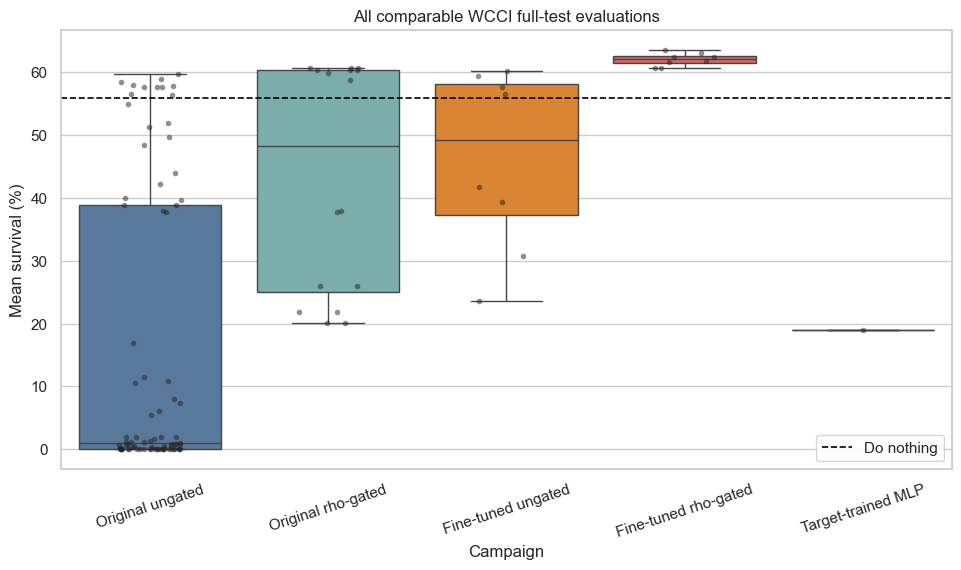

In [6]:
leaderboard_columns = [
    "rank_overall", "campaign", "family", "variant", "action_size",
    "heuristic", "rho_threshold", "checkpoint_global_step",
    "overall_mean_survival_percent", "overall_delta_vs_do_nothing_pp",
    "easy_preservation_rate", "difficult_mean_survival_percent",
    "difficult_median_survival_percent", "difficult_win_rate",
    "difficult_loss_rate", "difficult_rescues",
    "difficult_nonrescue_mean_delta_pp", "mean_executed_nonidle_rate",
    "mean_policy_nonidle_rate",
]
display(run_metrics[leaderboard_columns].head(20))

campaign_summary = (
    run_metrics.groupby("campaign", as_index=False)
    .agg(
        evaluations=("result_key", "size"),
        mean_overall=("overall_mean_survival_percent", "mean"),
        median_overall=("overall_mean_survival_percent", "median"),
        best_overall=("overall_mean_survival_percent", "max"),
        best_difficult_mean=("difficult_mean_survival_percent", "max"),
        best_difficult_median=("difficult_median_survival_percent", "max"),
    )
)
campaign_summary["campaign"] = pd.Categorical(
    campaign_summary["campaign"], categories=CAMPAIGN_ORDER, ordered=True
)
campaign_summary = campaign_summary.sort_values("campaign")
display(campaign_summary)

fig, ax = plt.subplots(figsize=(11.5, 5.7))
plot_order = [campaign for campaign in CAMPAIGN_ORDER if campaign in set(run_metrics["campaign"])]
sns.boxplot(
    data=run_metrics, x="campaign", y="overall_mean_survival_percent",
    order=plot_order, hue="campaign", palette=CAMPAIGN_COLORS,
    legend=False, showfliers=False, ax=ax,
)
sns.stripplot(
    data=run_metrics, x="campaign", y="overall_mean_survival_percent",
    order=plot_order, color="#222222", alpha=0.5, size=4, jitter=0.18, ax=ax,
)
ax.axhline(100 * baseline["do_nothing_survival"].mean(), color="black", linestyle="--", linewidth=1.2, label="Do nothing")
ax.set(
    xlabel="Campaign",
    ylabel="Mean survival (%)",
    title="All comparable WCCI full-test evaluations",
)
ax.tick_params(axis="x", rotation=18)
ax.legend(loc="lower right")
save_figure(fig, "all_campaign_overview")
plt.show()


## 5. Original zero-shot action-space sweep

These 80 ungated runs isolate the action cap and NL/NLS architecture
factors before fine-tuning or intervention heuristics.


,family,action_size,models,mean_overall,median_overall,best_overall,mean_nonidle
0,NL,64.000,8,22.955,9.462,58.002,0.202
1,NL,128.000,8,19.912,6.348,57.699,0.315
2,NL,256.000,8,14.224,4.263,54.989,0.390
3,NL,512.000,8,8.229,1.265,43.968,0.440
4,NL,"1,024.000",8,5.542,0.790,39.750,0.457
5,NLS,64.000,8,27.702,26.647,57.769,0.303
6,NLS,128.000,8,19.779,1.398,58.976,0.411
7,NLS,256.000,8,19.679,0.969,59.748,0.442
8,NLS,512.000,8,18.119,3.586,56.493,0.485
9,NLS,"1,024.000",8,0.933,0.172,5.466,0.478


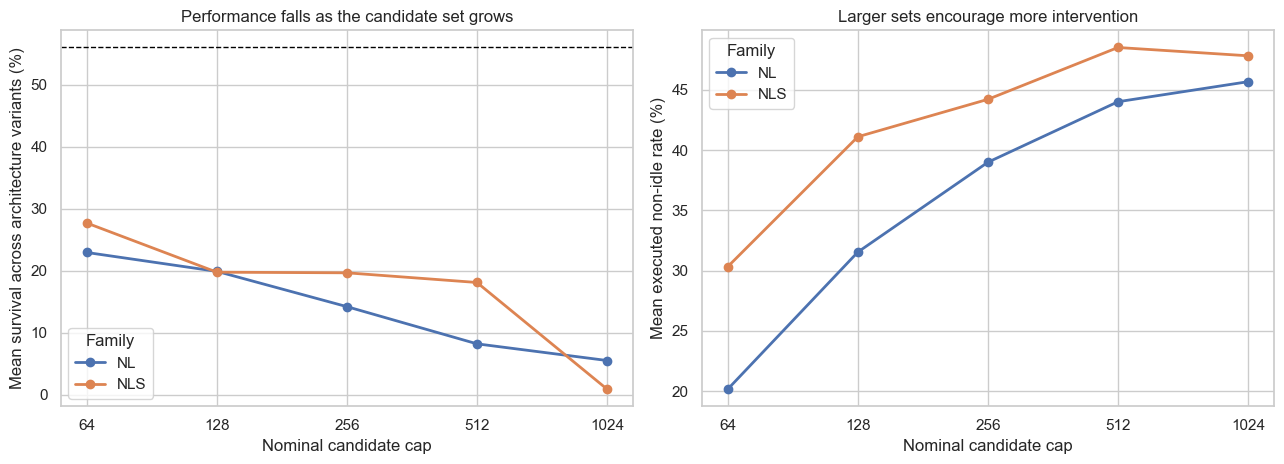

In [7]:
zero_shot = run_metrics.loc[
    (run_metrics["campaign"] == "Original ungated")
    & run_metrics["action_size"].isin(ACTION_ORDER)
].copy()
zero_shot_cap = (
    zero_shot.groupby(["family", "action_size"], as_index=False)
    .agg(
        models=("result_key", "size"),
        mean_overall=("overall_mean_survival_percent", "mean"),
        median_overall=("overall_mean_survival_percent", "median"),
        best_overall=("overall_mean_survival_percent", "max"),
        mean_nonidle=("mean_executed_nonidle_rate", "mean"),
    )
)
display(zero_shot_cap)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
for family, group in zero_shot_cap.groupby("family"):
    group = group.sort_values("action_size")
    axes[0].plot(group["action_size"], group["mean_overall"], marker="o", linewidth=2, label=family)
    axes[1].plot(group["action_size"], 100 * group["mean_nonidle"], marker="o", linewidth=2, label=family)
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xticks(ACTION_ORDER, ACTION_ORDER)
    ax.set_xlabel("Nominal candidate cap")
    ax.legend(title="Family")
axes[0].axhline(100 * baseline["do_nothing_survival"].mean(), color="black", linestyle="--", linewidth=1)
axes[0].set_ylabel("Mean survival across architecture variants (%)")
axes[0].set_title("Performance falls as the candidate set grows")
axes[1].set_ylabel("Mean executed non-idle rate (%)")
axes[1].set_title("Larger sets encourage more intervention")
fig.tight_layout()
save_figure(fig, "zero_shot_action_cap")
plt.show()


## 6. Early fine-tuning versus matched original mk256 models

Each line connects the same architecture variant before and after
early WCCI fine-tuning. The checkpoints were selected very early
(roughly 0.17M–2.99M steps), so this is evidence of rapid adaptation,
not a converged fine-tuning comparison.


,variant,checkpoint_global_step,finetuned_overall,finetuned_difficult_mean,finetuned_easy_preservation,finetuned_nonrescue_delta,original_overall,original_difficult_mean,original_easy_preservation,original_nonrescue_delta,overall_gain_pp
0,NLS_mean_f1_a0h0,165888,60.272,17.234,1.000,1.597,57.663,15.216,0.923,3.068,2.610
1,NLS_tmean_f1_a0h1,1078272,59.452,17.945,0.923,-1.507,37.900,1.150,0.538,-7.190,21.553
2,NLS_tmean_f0_a0h0,165888,57.707,13.326,0.923,-2.667,59.748,17.432,0.962,-2.093,-2.041
3,NLS_tmean_f1_a0h0,995328,56.647,14.009,0.923,2.269,0.063,0.074,0.000,-8.266,56.585
4,NLS_tmean_f0_a0h1,580608,41.762,3.999,0.692,-4.341,0.674,0.856,0.000,-7.484,41.089
5,NLS_mean_f0_a0h0,1410048,39.407,18.359,0.385,-1.034,0.051,0.052,0.000,-8.288,39.356
6,NLS_mean_f0_a0h1,2985984,30.745,5.372,0.385,-2.968,0.072,0.071,0.000,-8.269,30.674
7,NLS_mean_f1_a0h1,1658880,23.543,2.239,0.192,-6.101,1.264,1.898,0.000,-6.442,22.279


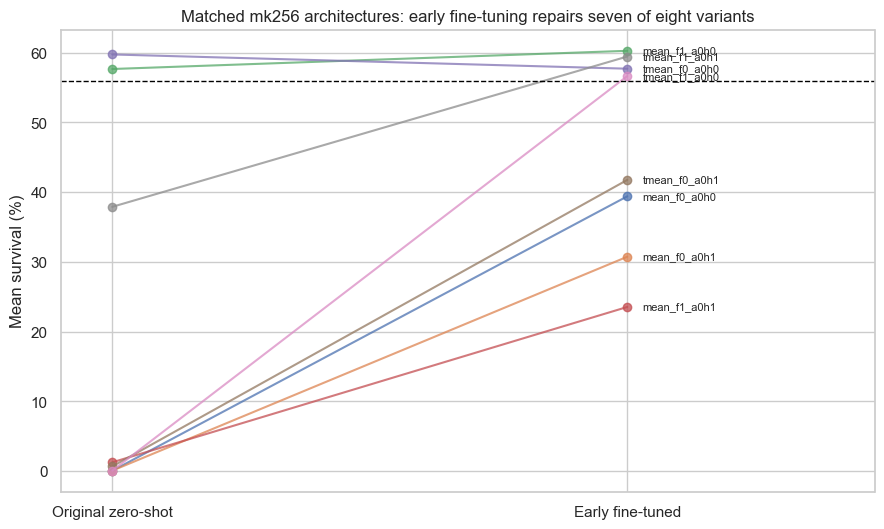

In [8]:
original_256 = run_metrics.loc[
    (run_metrics["campaign"] == "Original ungated")
    & (run_metrics["family"] == "NLS")
    & (run_metrics["action_size"] == 256),
    ["variant", "overall_mean_survival_percent", "difficult_mean_survival_percent",
     "easy_preservation_rate", "difficult_nonrescue_mean_delta_pp"]
].rename(columns={
    "overall_mean_survival_percent": "original_overall",
    "difficult_mean_survival_percent": "original_difficult_mean",
    "easy_preservation_rate": "original_easy_preservation",
    "difficult_nonrescue_mean_delta_pp": "original_nonrescue_delta",
})
fine_ungated = run_metrics.loc[
    run_metrics["campaign"] == "Fine-tuned ungated",
    ["variant", "checkpoint_global_step", "overall_mean_survival_percent",
     "difficult_mean_survival_percent", "easy_preservation_rate",
     "difficult_nonrescue_mean_delta_pp"]
].rename(columns={
    "overall_mean_survival_percent": "finetuned_overall",
    "difficult_mean_survival_percent": "finetuned_difficult_mean",
    "easy_preservation_rate": "finetuned_easy_preservation",
    "difficult_nonrescue_mean_delta_pp": "finetuned_nonrescue_delta",
})
matched_finetuning = fine_ungated.merge(original_256, on="variant", validate="one_to_one")
matched_finetuning["overall_gain_pp"] = (
    matched_finetuning["finetuned_overall"] - matched_finetuning["original_overall"]
)
matched_finetuning = matched_finetuning.sort_values("finetuned_overall", ascending=False)
display(matched_finetuning)

long_ft = matched_finetuning.melt(
    id_vars="variant", value_vars=["original_overall", "finetuned_overall"],
    var_name="regime", value_name="overall",
)
fig, ax = plt.subplots(figsize=(10.5, 6.0))
xmap = {"original_overall": 0, "finetuned_overall": 1}
for variant, group in long_ft.groupby("variant"):
    group = group.assign(x=group["regime"].map(xmap)).sort_values("x")
    ax.plot(group["x"], group["overall"], marker="o", alpha=0.75, linewidth=1.5)
    ax.text(1.03, group.iloc[-1]["overall"], variant.replace("NLS_", ""), va="center", fontsize=8)
ax.axhline(100 * baseline["do_nothing_survival"].mean(), color="black", linestyle="--", linewidth=1)
ax.set_xticks([0, 1], ["Original zero-shot", "Early fine-tuned"])
ax.set_xlim(-0.1, 1.48)
ax.set_ylabel("Mean survival (%)")
ax.set_title("Matched mk256 architectures: early fine-tuning repairs seven of eight variants")
save_figure(fig, "matched_early_finetuning")
plt.show()


## 7. Evaluation-only rho gating on fine-tuned checkpoints

Policy non-idle rate is measured before the heuristic override;
executed non-idle rate is measured after it. Their separation shows
how much intervention timing is supplied by the heuristic rather than
learned by the actor.


,rank_overall,campaign,family,variant,action_size,heuristic,rho_threshold,checkpoint_global_step,overall_mean_survival_percent,overall_delta_vs_do_nothing_pp,easy_preservation_rate,difficult_mean_survival_percent,difficult_median_survival_percent,difficult_win_rate,difficult_loss_rate,difficult_rescues,difficult_nonrescue_mean_delta_pp,mean_executed_nonidle_rate,mean_policy_nonidle_rate
1,2,Fine-tuned rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.900,1410048,63.047,7.044,1.000,23.014,7.374,0.417,0.542,4.000,0.308,0.004,0.436
0,1,Fine-tuned rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.950,1410048,63.594,7.590,1.000,24.153,8.875,0.417,0.500,4.000,1.675,0.001,0.451
7,8,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,global rho,0.900,165888,60.720,4.717,1.000,18.167,5.991,0.333,0.417,3.000,-1.253,0.010,0.470
6,7,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,global rho,0.950,165888,60.730,4.727,1.000,18.187,6.010,0.333,0.500,3.000,-1.230,0.003,0.505
5,6,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,0.850,165888,61.692,5.689,1.000,20.191,5.656,0.417,0.542,3.000,1.060,0.006,0.459
4,5,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,0.900,165888,61.899,5.896,1.000,20.622,6.053,0.500,0.417,3.000,1.553,0.002,0.475
2,3,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,0.950,165888,62.515,6.511,1.000,21.905,5.638,0.333,0.542,4.000,-1.023,0.001,0.487
3,4,Fine-tuned rho-gated,NLS,NLS_mean_f1_a0h0,256.000,local rho,1.000,165888,62.427,6.424,1.000,21.723,5.315,0.292,0.542,4.000,-1.241,0.000,0.536


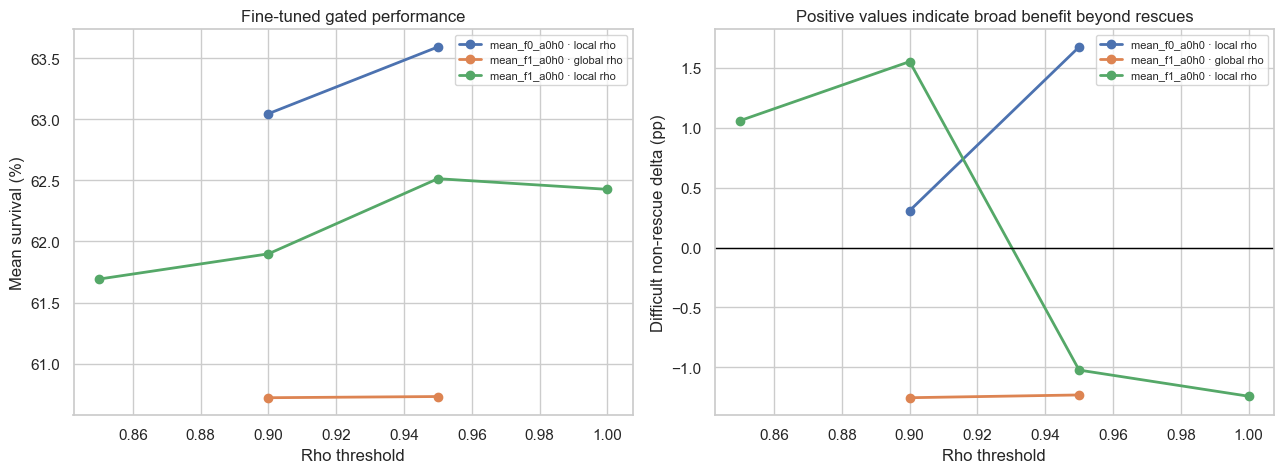

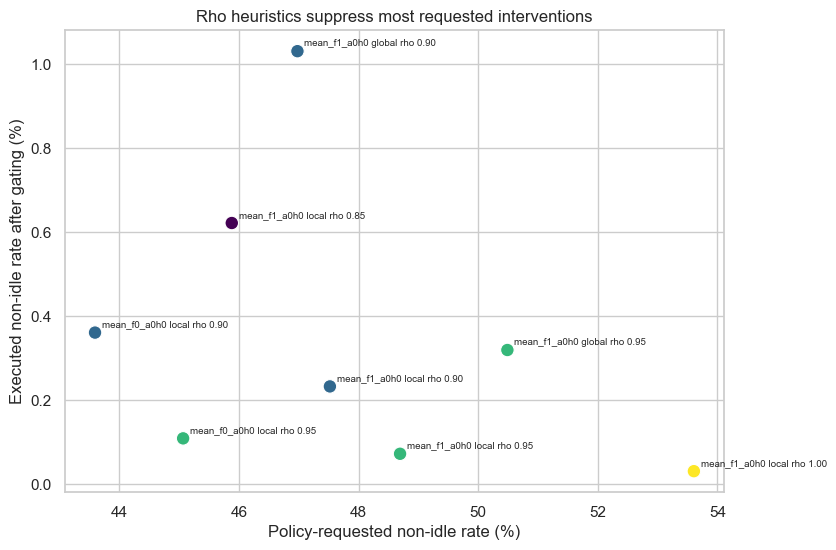

In [9]:
ft_gate = run_metrics.loc[
    run_metrics["campaign"] == "Fine-tuned rho-gated"
].copy().sort_values(["variant", "heuristic", "rho_threshold"])
display(ft_gate[leaderboard_columns])

ft_reference = run_metrics.loc[
    run_metrics["campaign"] == "Fine-tuned ungated",
    ["variant", "overall_mean_survival_percent"]
].set_index("variant")["overall_mean_survival_percent"]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.9))
for (variant, heuristic), group in ft_gate.groupby(["variant", "heuristic"]):
    group = group.sort_values("rho_threshold")
    label = f"{variant.replace('NLS_', '')} · {heuristic}"
    axes[0].plot(group["rho_threshold"], group["overall_mean_survival_percent"], marker="o", linewidth=2, label=label)
    axes[1].plot(group["rho_threshold"], group["difficult_nonrescue_mean_delta_pp"], marker="o", linewidth=2, label=label)
axes[0].set_ylabel("Mean survival (%)")
axes[0].set_title("Fine-tuned gated performance")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Difficult non-rescue delta (pp)")
axes[1].set_title("Positive values indicate broad benefit beyond rescues")
for ax in axes:
    ax.set_xlabel("Rho threshold")
    ax.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "finetuned_rho_thresholds")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6.0))
ax.scatter(
    100 * ft_gate["mean_policy_nonidle_rate"],
    100 * ft_gate["mean_executed_nonidle_rate"],
    c=ft_gate["rho_threshold"], cmap="viridis", s=95,
    edgecolor="white", linewidth=0.8,
)
for row in ft_gate.itertuples():
    ax.annotate(
        f"{row.variant.replace('NLS_', '')} {row.heuristic} {row.rho_threshold:.2f}",
        (100 * row.mean_policy_nonidle_rate, 100 * row.mean_executed_nonidle_rate),
        xytext=(5, 4), textcoords="offset points", fontsize=7,
    )
ax.set(
    xlabel="Policy-requested non-idle rate (%)",
    ylabel="Executed non-idle rate after gating (%)",
    title="Rho heuristics suppress most requested interventions",
)
save_figure(fig, "finetuned_policy_vs_executed_actions")
plt.show()


## 8. Local rho gating on original bus14 weights: mk64 versus mk256

This factorial sweep asks whether gating alone is sufficient or
whether fine-tuning also improves action ranking in dangerous states.


,rank_overall,campaign,family,variant,action_size,heuristic,rho_threshold,checkpoint_global_step,overall_mean_survival_percent,overall_delta_vs_do_nothing_pp,easy_preservation_rate,difficult_mean_survival_percent,difficult_median_survival_percent,difficult_win_rate,difficult_loss_rate,difficult_rescues,difficult_nonrescue_mean_delta_pp,mean_executed_nonidle_rate,mean_policy_nonidle_rate
53,54,Original rho-gated,NLS,NLS_mean_f0_a0h0,64.000,local rho,0.850,14929920,20.140,-35.863,0.192,4.333,4.025,0.000,0.875,0.000,-4.007,0.005,0.403
52,53,Original rho-gated,NLS,NLS_mean_f0_a0h0,64.000,local rho,0.900,14929920,21.820,-34.183,0.192,4.405,4.025,0.000,0.875,0.000,-3.935,0.002,0.411
49,50,Original rho-gated,NLS,NLS_mean_f0_a0h0,64.000,local rho,0.950,14929920,26.033,-29.970,0.192,5.210,4.806,0.042,0.833,0.000,-3.130,0.001,0.435
44,45,Original rho-gated,NLS,NLS_mean_f0_a0h0,64.000,local rho,1.000,14929920,37.888,-18.116,0.538,6.210,5.334,0.208,0.625,0.000,-2.130,0.000,0.456
54,55,Original rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.850,14929920,20.039,-35.964,0.192,4.123,2.251,0.042,0.917,0.000,-4.217,0.005,0.560
51,52,Original rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.900,14929920,21.876,-34.127,0.192,4.522,4.112,0.167,0.792,0.000,-3.818,0.002,0.569
48,49,Original rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.950,14929920,26.060,-29.943,0.192,5.266,5.346,0.250,0.708,0.000,-3.074,0.001,0.596
46,47,Original rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,1.000,14929920,37.768,-18.235,0.538,5.961,5.365,0.333,0.625,0.000,-2.379,0.000,0.623
19,20,Original rho-gated,NLS,NLS_tmean_f0_a0h0,64.000,local rho,0.850,14929920,58.745,2.742,1.000,14.053,5.272,0.292,0.625,1.000,2.315,0.001,0.037
15,16,Original rho-gated,NLS,NLS_tmean_f0_a0h0,64.000,local rho,0.900,14929920,59.845,3.842,1.000,16.344,5.315,0.292,0.625,1.000,4.705,0.001,0.057


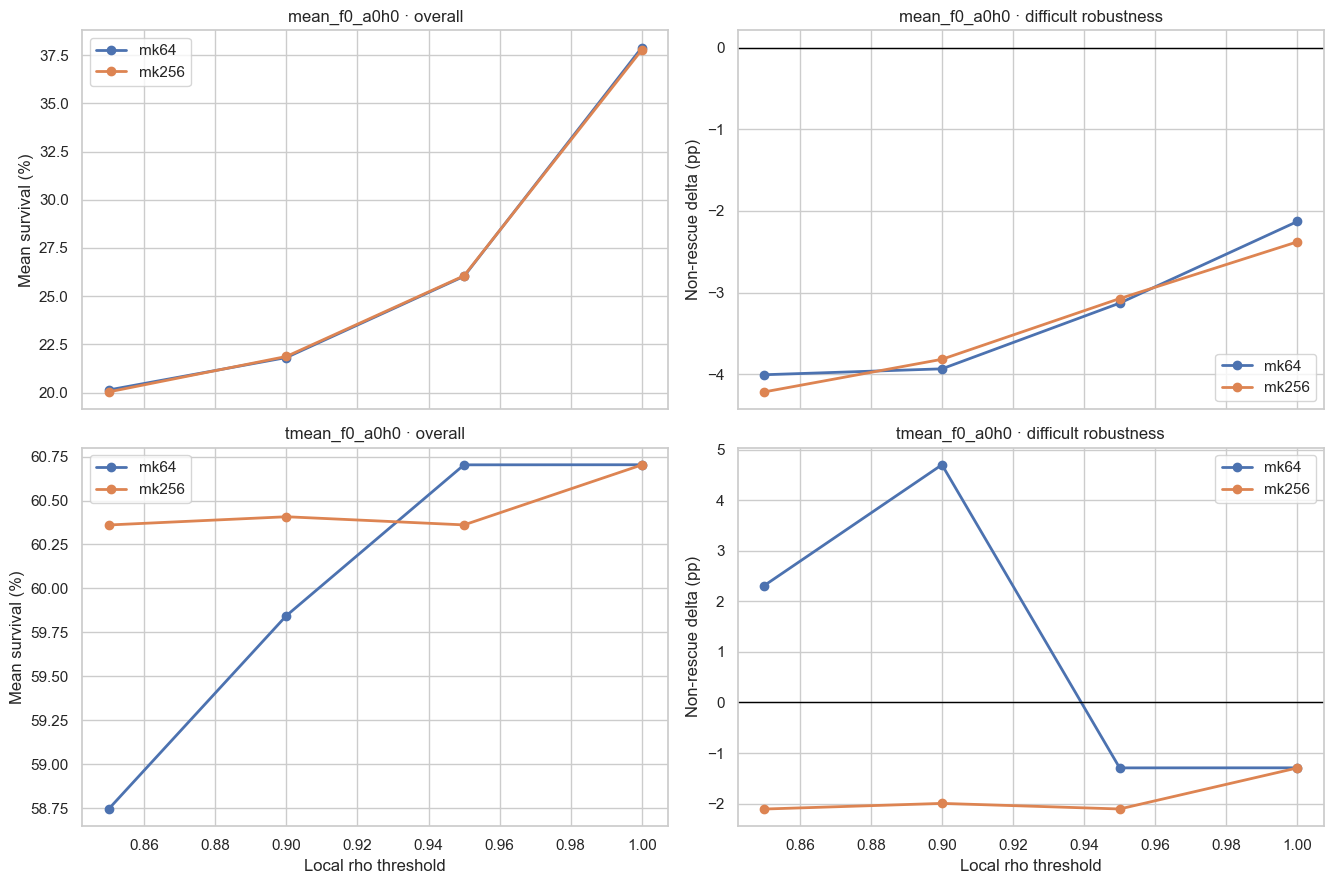

In [10]:
original_gate = run_metrics.loc[
    run_metrics["campaign"] == "Original rho-gated"
].copy().sort_values(["variant", "action_size", "rho_threshold"])
display(original_gate[leaderboard_columns])

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0), sharex=True)
gated_variants = list(original_gate["variant"].drop_duplicates())
for row_index, variant in enumerate(gated_variants):
    subset = original_gate.loc[original_gate["variant"] == variant]
    for action_size, group in subset.groupby("action_size"):
        group = group.sort_values("rho_threshold")
        label = f"mk{int(action_size)}"
        axes[row_index, 0].plot(group["rho_threshold"], group["overall_mean_survival_percent"], marker="o", linewidth=2, label=label)
        axes[row_index, 1].plot(group["rho_threshold"], group["difficult_nonrescue_mean_delta_pp"], marker="o", linewidth=2, label=label)
    axes[row_index, 0].set_ylabel("Mean survival (%)")
    axes[row_index, 0].set_title(variant.replace("NLS_", "") + " · overall")
    axes[row_index, 1].axhline(0, color="black", linewidth=1)
    axes[row_index, 1].set_ylabel("Non-rescue delta (pp)")
    axes[row_index, 1].set_title(variant.replace("NLS_", "") + " · difficult robustness")
    axes[row_index, 0].legend()
    axes[row_index, 1].legend()
for ax in axes[-1, :]:
    ax.set_xlabel("Local rho threshold")
fig.tight_layout()
save_figure(fig, "original_rho_cap_sweep")
plt.show()


## 9. Best systems and chronic-level anatomy

The heatmap shows paired survival deltas on the 24 difficult
chronics. Large isolated positive cells identify rescue-driven means;
modest positive values across many columns indicate broader benefit.


,selection,campaign,family,variant,action_size,heuristic,rho_threshold,checkpoint_global_step,overall_mean_survival_percent,overall_delta_vs_do_nothing_pp,easy_preservation_rate,difficult_mean_survival_percent,difficult_median_survival_percent,difficult_win_rate,difficult_loss_rate,difficult_rescues,difficult_nonrescue_mean_delta_pp,mean_executed_nonidle_rate,mean_policy_nonidle_rate
0,Best original ungated,Original ungated,NLS,NLS_tmean_f0_a0h0,256.000,none,NaN,14929920,59.748,3.745,0.962,17.432,5.272,0.250,0.583,3.000,-2.093,0.244,0.244
1,Best original gated,Original rho-gated,NLS,NLS_tmean_f0_a0h0,64.000,local rho,1.000,14929920,60.704,4.700,1.000,18.132,5.327,0.292,0.583,3.000,-1.293,0.000,0.085
2,Best fine-tuned ungated,Fine-tuned ungated,NLS,NLS_mean_f1_a0h0,256.000,none,NaN,165888,60.272,4.269,1.000,17.234,5.662,0.292,0.417,2.000,1.597,0.415,0.415
3,Best fine-tuned gated,Fine-tuned rho-gated,NLS,NLS_mean_f0_a0h0,256.000,local rho,0.950,1410048,63.594,7.590,1.000,24.153,8.875,0.417,0.500,4.000,1.675,0.001,0.451
4,Target-trained MLP,Target-trained MLP,MLP,target_trained_mlp,NaN,none,NaN,43628544,19.033,-36.970,0.038,12.087,6.065,0.417,0.583,0.000,3.746,0.780,0.780


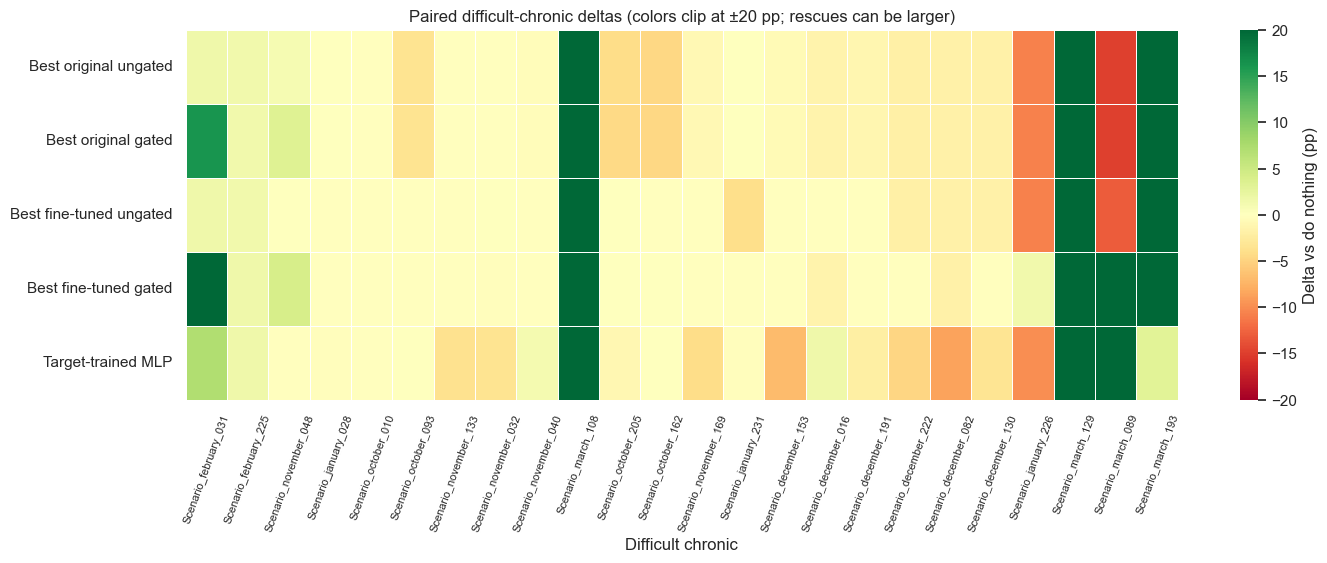

In [11]:
def best_key(campaign):
    return run_metrics.loc[
        run_metrics["campaign"] == campaign
    ].sort_values("overall_mean_survival_percent", ascending=False).iloc[0]["result_key"]


selected_keys = {
    "Best original ungated": best_key("Original ungated"),
    "Best original gated": best_key("Original rho-gated"),
    "Best fine-tuned ungated": best_key("Fine-tuned ungated"),
    "Best fine-tuned gated": best_key("Fine-tuned rho-gated"),
}
if "Target-trained MLP" in set(run_metrics["campaign"]):
    selected_keys["Target-trained MLP"] = best_key("Target-trained MLP")

selected_comparison = run_metrics.set_index("result_key").loc[
    list(selected_keys.values())
].reset_index()
selected_comparison.insert(0, "selection", list(selected_keys.keys()))
display(selected_comparison[["selection", *leaderboard_columns[1:]]])

hard_episodes = episodes.loc[episodes["cohort"] == "Do-nothing < 100%"]
heatmap_rows = []
for selection, key in selected_keys.items():
    frame = hard_episodes.loc[hard_episodes["result_key"] == key, [
        "chronic_name", "delta_vs_do_nothing_pp"
    ]].copy()
    frame["selection"] = selection
    heatmap_rows.append(frame)
heatmap_long = pd.concat(heatmap_rows, ignore_index=True)
chronic_order = (
    baseline.loc[~baseline["do_nothing_full_survival"]]
    .sort_values("do_nothing_survival")["chronic_name"].tolist()
)
heatmap = heatmap_long.pivot(index="selection", columns="chronic_name", values="delta_vs_do_nothing_pp")
heatmap = heatmap.reindex(index=list(selected_keys), columns=chronic_order)
fig, ax = plt.subplots(figsize=(16.0, 4.8))
sns.heatmap(
    heatmap, cmap="RdYlGn", center=0, vmin=-20, vmax=20,
    linewidths=0.4, linecolor="white", cbar_kws={"label": "Delta vs do nothing (pp)"},
    ax=ax,
)
ax.set_xlabel("Difficult chronic")
ax.set_ylabel("")
ax.set_title("Paired difficult-chronic deltas (colors clip at ±20 pp; rescues can be larger)")
ax.tick_params(axis="x", labelrotation=70, labelsize=8)
save_figure(fig, "best_systems_difficult_heatmap")
plt.show()


In [12]:
best_gated_key = selected_keys["Best fine-tuned gated"]
best_gated_episodes = episodes.loc[episodes["result_key"] == best_gated_key]
best_gated_hard = best_gated_episodes.loc[
    best_gated_episodes["cohort"] == "Do-nothing < 100%"
]
rescue_mask = best_gated_hard["model_full_survival"]
best_contributions = pd.DataFrame([
    {
        "component": "Fully rescued difficult chronics",
        "episodes": int(rescue_mask.sum()),
        "contribution_to_50_episode_mean_pp": (
            best_gated_hard.loc[rescue_mask, "delta_vs_do_nothing_pp"].sum() / 50
        ),
    },
    {
        "component": "Other difficult chronics",
        "episodes": int((~rescue_mask).sum()),
        "contribution_to_50_episode_mean_pp": (
            best_gated_hard.loc[~rescue_mask, "delta_vs_do_nothing_pp"].sum() / 50
        ),
    },
    {
        "component": "Do-nothing-perfect chronics",
        "episodes": 26,
        "contribution_to_50_episode_mean_pp": (
            best_gated_episodes.loc[
                best_gated_episodes["cohort"] == "Do-nothing = 100%",
                "delta_vs_do_nothing_pp",
            ].sum() / 50
        ),
    },
])
display(best_contributions)
display(best_gated_hard.loc[rescue_mask, [
    "chronic_name", "do_nothing_survival", "survival", "delta_vs_do_nothing_pp"
]].sort_values("delta_vs_do_nothing_pp", ascending=False))


,component,episodes,contribution_to_50_episode_mean_pp
0,Fully rescued difficult chronics,4,6.920
1,Other difficult chronics,20,0.670
2,Do-nothing-perfect chronics,26,0.000


,chronic_name,do_nothing_survival,survival,delta_vs_do_nothing_pp
4473,Scenario_march_108,0.055,1.000,94.468
4470,Scenario_march_129,0.161,1.000,83.863
4451,Scenario_march_089,0.161,1.000,83.850
4491,Scenario_march_193,0.162,1.000,83.838


## 10. Paired bootstrap comparisons

Bootstrap intervals resample the 50 chronic pairs. They describe
chronic-set uncertainty for these fixed checkpoints; they do not
account for training-seed uncertainty or the optimistic bias from
selecting methods on this same test set.


In [13]:
RNG = np.random.default_rng(20260817)


def paired_bootstrap(key_a, key_b=None, n_boot=50_000):
    a = episodes.loc[episodes["result_key"] == key_a, [
        "chronic_fingerprint", "survival"
    ]].rename(columns={"survival": "a"})
    if key_b is None:
        data = a.merge(
            baseline[["chronic_fingerprint", "do_nothing_survival"]],
            on="chronic_fingerprint", validate="one_to_one",
        )
        delta = 100 * (data["a"] - data["do_nothing_survival"]).to_numpy()
    else:
        b = episodes.loc[episodes["result_key"] == key_b, [
            "chronic_fingerprint", "survival"
        ]].rename(columns={"survival": "b"})
        data = a.merge(b, on="chronic_fingerprint", validate="one_to_one")
        delta = 100 * (data["a"] - data["b"]).to_numpy()
    indices = RNG.integers(0, len(delta), size=(n_boot, len(delta)))
    bootstrap_means = delta[indices].mean(axis=1)
    return {
        "mean_delta_pp": delta.mean(),
        "median_delta_pp": np.median(delta),
        "wins": int((delta > 1e-9).sum()),
        "ties": int((np.abs(delta) <= 1e-9).sum()),
        "losses": int((delta < -1e-9).sum()),
        "ci95_low_pp": np.quantile(bootstrap_means, 0.025),
        "ci95_high_pp": np.quantile(bootstrap_means, 0.975),
    }


comparison_pairs = [
    ("Best fine-tuned gated", None, "Do nothing"),
    ("Best fine-tuned gated", "Best fine-tuned ungated", "Best fine-tuned ungated"),
    ("Best fine-tuned gated", "Best original gated", "Best original gated"),
    ("Best fine-tuned gated", "Best original ungated", "Best original ungated"),
]
bootstrap_rows = []
for a_label, b_label, comparison_label in comparison_pairs:
    result = paired_bootstrap(
        selected_keys[a_label], selected_keys[b_label] if b_label else None
    )
    result.update({"method": a_label, "comparison": comparison_label})
    bootstrap_rows.append(result)
bootstrap_comparisons = pd.DataFrame(bootstrap_rows)[[
    "method", "comparison", "mean_delta_pp", "median_delta_pp",
    "wins", "ties", "losses", "ci95_low_pp", "ci95_high_pp",
]]
display(bootstrap_comparisons)


,method,comparison,mean_delta_pp,median_delta_pp,wins,ties,losses,ci95_low_pp,ci95_high_pp
0,Best fine-tuned gated,Do nothing,7.590,0.000,10,28,12,1.785,14.749
1,Best fine-tuned gated,Best fine-tuned ungated,3.321,0.000,13,31,6,0.432,7.864
2,Best fine-tuned gated,Best original gated,2.890,0.000,15,29,6,0.401,7.249
3,Best fine-tuned gated,Best original ungated,3.845,0.000,16,28,6,0.754,8.659


## 11. Conclusions from the complete downloaded evidence

1. **Candidate ranking and intervention timing are separate transfer
   problems.** Large candidate sets degrade ungated zero-shot models,
   while local rho gating can preserve useful actions in dangerous
   states and suppress nearly all safe-state requests.
2. **Fine-tuning contributes beyond gating.** Gating repairs the best
   original typed-mean model modestly, but it cannot rescue the
   original mean-f0 model to the level reached after fine-tuning.
3. **The strongest current system is hybrid.** The fine-tuned
   `mean_f0_a0h0` checkpoint with local rho 0.95 combines perfect easy
   preservation, four difficult rescues, and a positive mean delta on
   its remaining difficult chronics.
4. **The learned actor still lacks reliable act/do-nothing
   calibration.** For the best hybrid, the policy requests actions
   frequently while the local heuristic executes only a tiny fraction.
   This motivates a learned two-stage intervention gate.
5. **Threshold selection must move off the test set.** Use validation
   chronics to select the cap and rho threshold, then evaluate once on
   fresh held-out chronics and repeat training over multiple seeds.


## 12. Export all tables and figures


In [14]:
inventory.drop(columns=["action_artifacts"]).to_csv(
    EXPORT_DIR / "complete_result_inventory.csv", index=False
)
source_results.to_csv(EXPORT_DIR / "source_grid_results.csv", index=False)
episodes.to_csv(EXPORT_DIR / "all_wcci_episode_metrics.csv", index=False)
agent_behavior.to_csv(EXPORT_DIR / "all_wcci_agent_behavior.csv", index=False)
run_metrics.to_csv(EXPORT_DIR / "all_wcci_run_metrics.csv", index=False)
campaign_summary.to_csv(EXPORT_DIR / "campaign_summary.csv", index=False)
zero_shot_cap.to_csv(EXPORT_DIR / "zero_shot_action_cap_summary.csv", index=False)
matched_finetuning.to_csv(EXPORT_DIR / "matched_early_finetuning.csv", index=False)
ft_gate.to_csv(EXPORT_DIR / "finetuned_rho_sweep.csv", index=False)
original_gate.to_csv(EXPORT_DIR / "original_rho_cap_sweep.csv", index=False)
selected_comparison.to_csv(EXPORT_DIR / "selected_best_systems.csv", index=False)
best_contributions.to_csv(EXPORT_DIR / "best_system_mean_contributions.csv", index=False)
heatmap_long.to_csv(EXPORT_DIR / "best_systems_difficult_chronic_deltas.csv", index=False)
bootstrap_comparisons.to_csv(EXPORT_DIR / "paired_bootstrap_comparisons.csv", index=False)

best_row = run_metrics.iloc[0]
summary_lines = [
    "# Complete shared WCCI analysis summary",
    "",
    f"- Shared result JSONs inventoried: {len(shared_inventory)}.",
    f"- Comparable shared WCCI evaluations: {int(shared_inventory['is_wcci_50'].sum())}.",
    f"- WCCI evaluations including the external comparator: {len(wcci_inventory)}.",
    f"- WCCI model episodes: {len(episodes)}.",
    f"- Best current result: {best_row['overall_mean_survival_percent']:.3f}%.",
    f"- Best campaign: {best_row['campaign']}.",
    f"- Best variant: {best_row['variant']}.",
    f"- Best action cap: mk{int(best_row['action_size'])}.",
    f"- Best heuristic: {best_row['heuristic']} at rho={best_row['rho_threshold']:.2f}.",
    f"- Easy preservation: {100 * best_row['easy_preservation_rate']:.1f}%.",
    f"- Difficult mean / median: {best_row['difficult_mean_survival_percent']:.3f}% / {best_row['difficult_median_survival_percent']:.3f}%.",
    f"- Difficult rescues: {int(best_row['difficult_rescues'])}.",
    f"- Difficult non-rescue delta: {best_row['difficult_nonrescue_mean_delta_pp']:.3f} pp.",
    "",
    "Caveat: caps and rho thresholds were inspected on these same 50 test chronics; use validation and a fresh held-out set for final claims.",
]
(EXPORT_DIR / "complete_analysis_summary.md").write_text(
    "\n".join(summary_lines) + "\n", encoding="utf-8"
)
print("Exported complete analysis to:", EXPORT_DIR)


Exported complete analysis to: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/shared_wcci_complete_full_test
